# 01 逐品种总成交量与三个月移动平均

本 Notebook 复现论文《从高频视角看中国期货市场的演变历程》Figure 1：把同一品种所有固定月份合约的日成交量相加，再绘制 63 个品种交易日移动平均。

数据只从正式 silver 湖仓读取；本 Notebook 不写入 silver、gold 或其他数据文件。

## 在做什么

期货品种在同一天通常有多个到期月份同时交易。单看某一个合约会把换月造成的成交迁移误认为整个品种活跃度变化，因此先按“品种—交易日”汇总所有固定月份合约。

## 经济意义

总成交量衡量市场参与和交易活跃度；63 日均线压低日度噪声，用来观察季度尺度上的持续变化。它能描述活跃度如何演变，但不能单独证明监管、宏观冲击或参与者结构是变化原因。

## 论文口径

对品种 $u$、交易日 $t$：

$$V_u(t)=\sum_{T\in\mathcal{T}_u(t)}v(t,T)$$

$\mathcal{T}_u(t)$ 是当天可交易的全部固定月份合约，$v(t,T)$ 是对应合约成交量。论文称粗线为三个月移动平均；这里把三个月固定解释为 63 个品种交易日，并要求窗口完整。

默认样本为论文六品种与 2012-01-01 至 2021-12-31；NI 从 2015 年上市后才有观测。

## 代码步骤

1. 定位项目根目录并导入权威数据契约。
2. 设置论文样本；将日期改为 `None` 可以扩展到湖仓全历史。
3. 用 PyArrow Dataset 按品种和日期下推过滤，只读取需要的列。
4. 检查样本覆盖与本项计算所需的局部前提。
5. 按品种—交易日汇总全部合约成交量并计算 63 日均线。
6. 绘制 3×2 面板并复核移动平均。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import pathlib
import sys
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import FUTURES_DAILY_SCHEMA, arrow_to_pandas  # noqa: E402
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(f"schema_table: {FUTURES_DAILY_SCHEMA.metadata[b'table_name'].decode('utf-8')}")

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_table: fact_futures_daily


## 第 2 步：设置样本

要扩展到湖仓全历史，可把 `ANALYSIS_START_DATE` 或 `ANALYSIS_END_DATE` 改为 `None`。品种列表仍保持显式，避免把数据采集白名单误当成研究宇宙。

In [2]:
PAPER_START_DATE = date(2012, 1, 1)
PAPER_END_DATE = date(2021, 12, 31)
ANALYSIS_START_DATE: date | None = PAPER_START_DATE
ANALYSIS_END_DATE: date | None = PAPER_END_DATE
ROLLING_TRADING_DAYS = 63

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"}, # 螺纹钢 steel rebar
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},      # 铜 copper
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},      # 镍 nickel
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"}, # 豆粕 Soybean Meal
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},      # 塑料 Plastic
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},         # 玉米 Corn
]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}

pd.DataFrame(PRODUCTS)

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,M,Soybean Meal
4,XDCE,L,Plastic
5,XDCE,C,Corn


## 第 3 步：契约化读取日线

读取前从 `FUTURES_DAILY_SCHEMA` 取得表名、分区列和字段类型。筛选在 PyArrow Dataset 层执行，避免把整张日线事实表载入内存。

In [10]:
schema_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_DAILY_SCHEMA.metadata or {}).items()
}
table_name = schema_metadata["table_name"]
partition_columns = schema_metadata["partition_columns"].split(",")
daily_path = settings.futures_lake_root / "silver" / table_name
if not daily_path.exists():
    raise FileNotFoundError(f"日线事实表不存在：{daily_path}")

partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_DAILY_SCHEMA.field(column_name).type)
        for column_name in partition_columns
    ]
)
partitioning_schema

exchange_code: string
underlying_code: string
year: int16
month: int8

In [11]:
schema_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_DAILY_SCHEMA.metadata or {}).items()
}
table_name = schema_metadata["table_name"]
partition_columns = schema_metadata["partition_columns"].split(",")
daily_path = settings.futures_lake_root / "silver" / table_name
if not daily_path.exists():
    raise FileNotFoundError(f"日线事实表不存在：{daily_path}")

partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_DAILY_SCHEMA.field(column_name).type)
        for column_name in partition_columns
    ]
)
daily_dataset = ds.dataset(
    daily_path,
    format="parquet",
    partitioning=ds.partitioning(partitioning_schema, flavor="hive"),
)

required_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "volume",
    "has_market_data",
]
required_schema = pa.schema(
    [FUTURES_DAILY_SCHEMA.field(column_name) for column_name in required_columns]
)
for expected_field in required_schema:
    actual_field = daily_dataset.schema.field(expected_field.name)
    if actual_field.type != expected_field.type:
        raise TypeError(
            f"字段 {expected_field.name} 类型不匹配："
            f"期望 {expected_field.type}，实际 {actual_field.type}"
        )

product_filter = None
for exchange_code, underlying_code in PRODUCT_KEYS:
    current_product_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
    )
    product_filter = (
        current_product_filter
        if product_filter is None
        else product_filter | current_product_filter
    )

filter_expression = product_filter
if ANALYSIS_START_DATE is not None:
    filter_expression = filter_expression & (
        ds.field("trading_date") >= pa.scalar(ANALYSIS_START_DATE)
    )
if ANALYSIS_END_DATE is not None:
    filter_expression = filter_expression & (
        ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE)
    )

selected_daily_table = daily_dataset.to_table(
    columns=required_columns,
    filter=filter_expression,
)
daily_df = arrow_to_pandas(selected_daily_table, required_schema)
daily_df["trading_date"] = pd.to_datetime(daily_df["trading_date"])

print(f"daily_path: {daily_path}")
print(f"selected_contract_day_rows: {len(daily_df):,}")

daily_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_daily
selected_contract_day_rows: 141,254


## 第 4 步：检查覆盖和局部计算前提

正式 silver 已由生产者验证完整业务契约；这里不重复扫描上游质量，只检查本项统计直接需要的条件：六个目标品种存在、有效行情成交量非空且为有限非负数。

In [18]:
market_daily_df = daily_df.loc[
    daily_df["has_market_data"].fillna(False)
    & daily_df["volume"].notna()
].copy()
market_daily_df["volume"] = pd.to_numeric(
    market_daily_df["volume"], errors="raise"
).astype(float)

present_product_keys = set(
    market_daily_df[["exchange_code", "underlying_code"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
missing_product_keys = set(PRODUCT_KEYS) - present_product_keys
if missing_product_keys:
    raise ValueError(f"目标品种没有有效日线：{sorted(missing_product_keys)}")
if not np.isfinite(market_daily_df["volume"].to_numpy(dtype=float)).all():
    raise ValueError("有效行情成交量包含非有限值")
if (market_daily_df["volume"] < 0).any():
    raise ValueError("有效行情成交量包含负值")

coverage_df = (
    market_daily_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_trading_date=("trading_date", "min"),
        last_trading_date=("trading_date", "max"),
        trading_days=("trading_date", "nunique"),
        contracts=("contract_code", "nunique"),
        contract_day_rows=("contract_code", "size"),
        total_volume=("volume", "sum"),
    )
)
coverage_df["label"] = coverage_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
coverage_df["total_volume_million"] = coverage_df["total_volume"] / 1_000_000
coverage_df = coverage_df[
    [
        "exchange_code",
        "underlying_code",
        "label",
        "first_trading_date",
        "last_trading_date",
        "trading_days",
        "contracts",
        "contract_day_rows",
        "total_volume_million",
    ]
].sort_values(["exchange_code", "underlying_code"])

ni_first_date = coverage_df.loc[
    (coverage_df["exchange_code"] == "XSGE")
    & (coverage_df["underlying_code"] == "NI"),
    "first_trading_date",
].iloc[0]
if ni_first_date < pd.Timestamp(2015, 1, 1):
    raise AssertionError(f"NI 在上市前出现行情：{ni_first_date}")

display(coverage_df.reset_index(drop=True))

,exchange_code,underlying_code,label,first_trading_date,last_trading_date,trading_days,contracts,contract_day_rows,total_volume_million
0,XDCE,C,Corn,2012-01-04,2021-12-31,2431,66,14586,1403.285651
1,XDCE,L,Plastic,2012-01-04,2021-12-31,2431,132,29172,1430.922554
2,XDCE,M,Soybean Meal,2012-01-04,2021-12-31,2431,88,19448,5016.842321
3,XSGE,CU,Copper,2012-01-04,2021-12-31,2431,132,29169,1110.548513
4,XSGE,NI,Nickel,2015-03-27,2021-12-31,1651,90,19710,1378.444566
5,XSGE,RB,Steel Rebar,2012-01-04,2021-12-31,2431,132,29169,9133.473462


## 第 5 步：汇总全部合约并计算 63 日均线

先把同一品种同一交易日的所有合约成交量相加；`contributing_contracts` 同时保留当天有有效行情的合约数，便于解释总量由多少合约贡献。

In [19]:
volume_daily_df = (
    market_daily_df.groupby(
        ["exchange_code", "underlying_code", "trading_date"],
        observed=True,
        as_index=False,
    )
    .agg(
        total_volume=("volume", "sum"),
        contributing_contracts=("contract_code", "nunique"),
    )
    .sort_values(["exchange_code", "underlying_code", "trading_date"])
    .reset_index(drop=True)
)
volume_daily_df["volume_63d_mean"] = (
    volume_daily_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
    )["total_volume"]
    .transform(
        lambda volume_series: volume_series.rolling(
            window=ROLLING_TRADING_DAYS,
            min_periods=ROLLING_TRADING_DAYS,
        ).mean()
    )
)

daily_summary_df = (
    volume_daily_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
        as_index=False,
    )
    .agg(
        aggregated_trading_days=("trading_date", "size"),
        first_complete_63d_date=("trading_date", lambda values: values.iloc[62]),
        mean_daily_volume=("total_volume", "mean"),
        max_daily_volume=("total_volume", "max"),
    )
)
daily_summary_df["label"] = daily_summary_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
daily_summary_df["mean_daily_volume_million"] = (
    daily_summary_df["mean_daily_volume"] / 1_000_000
)
daily_summary_df["max_daily_volume_million"] = (
    daily_summary_df["max_daily_volume"] / 1_000_000
)
display(
    daily_summary_df[
        [
            "exchange_code",
            "underlying_code",
            "label",
            "aggregated_trading_days",
            "first_complete_63d_date",
            "mean_daily_volume_million",
            "max_daily_volume_million",
        ]
    ].sort_values(["exchange_code", "underlying_code"]).reset_index(drop=True)
)
print(f"aggregated_product_day_rows: {len(volume_daily_df):,}")

,exchange_code,underlying_code,label,aggregated_trading_days,first_complete_63d_date,mean_daily_volume_million,max_daily_volume_million
0,XDCE,C,Corn,2431,2012-04-11,0.577246,4.702794
1,XDCE,L,Plastic,2431,2012-04-11,0.588615,2.159264
2,XDCE,M,Soybean Meal,2431,2012-04-11,2.063695,11.868484
3,XSGE,CU,Copper,2431,2012-04-11,0.456828,2.369494
4,XSGE,NI,Nickel,1651,2015-06-26,0.834915,3.297834
5,XSGE,RB,Steel Rebar,2431,2012-04-11,3.757085,23.972128


aggregated_product_day_rows: 13,806


## 第 6 步：绘制 Figure 1 风格图

浅色细线是每日总成交量，粗线是完整 63 日移动平均。纵轴统一换算为百万手，便于六个面板阅读；每个面板仍使用自身尺度。

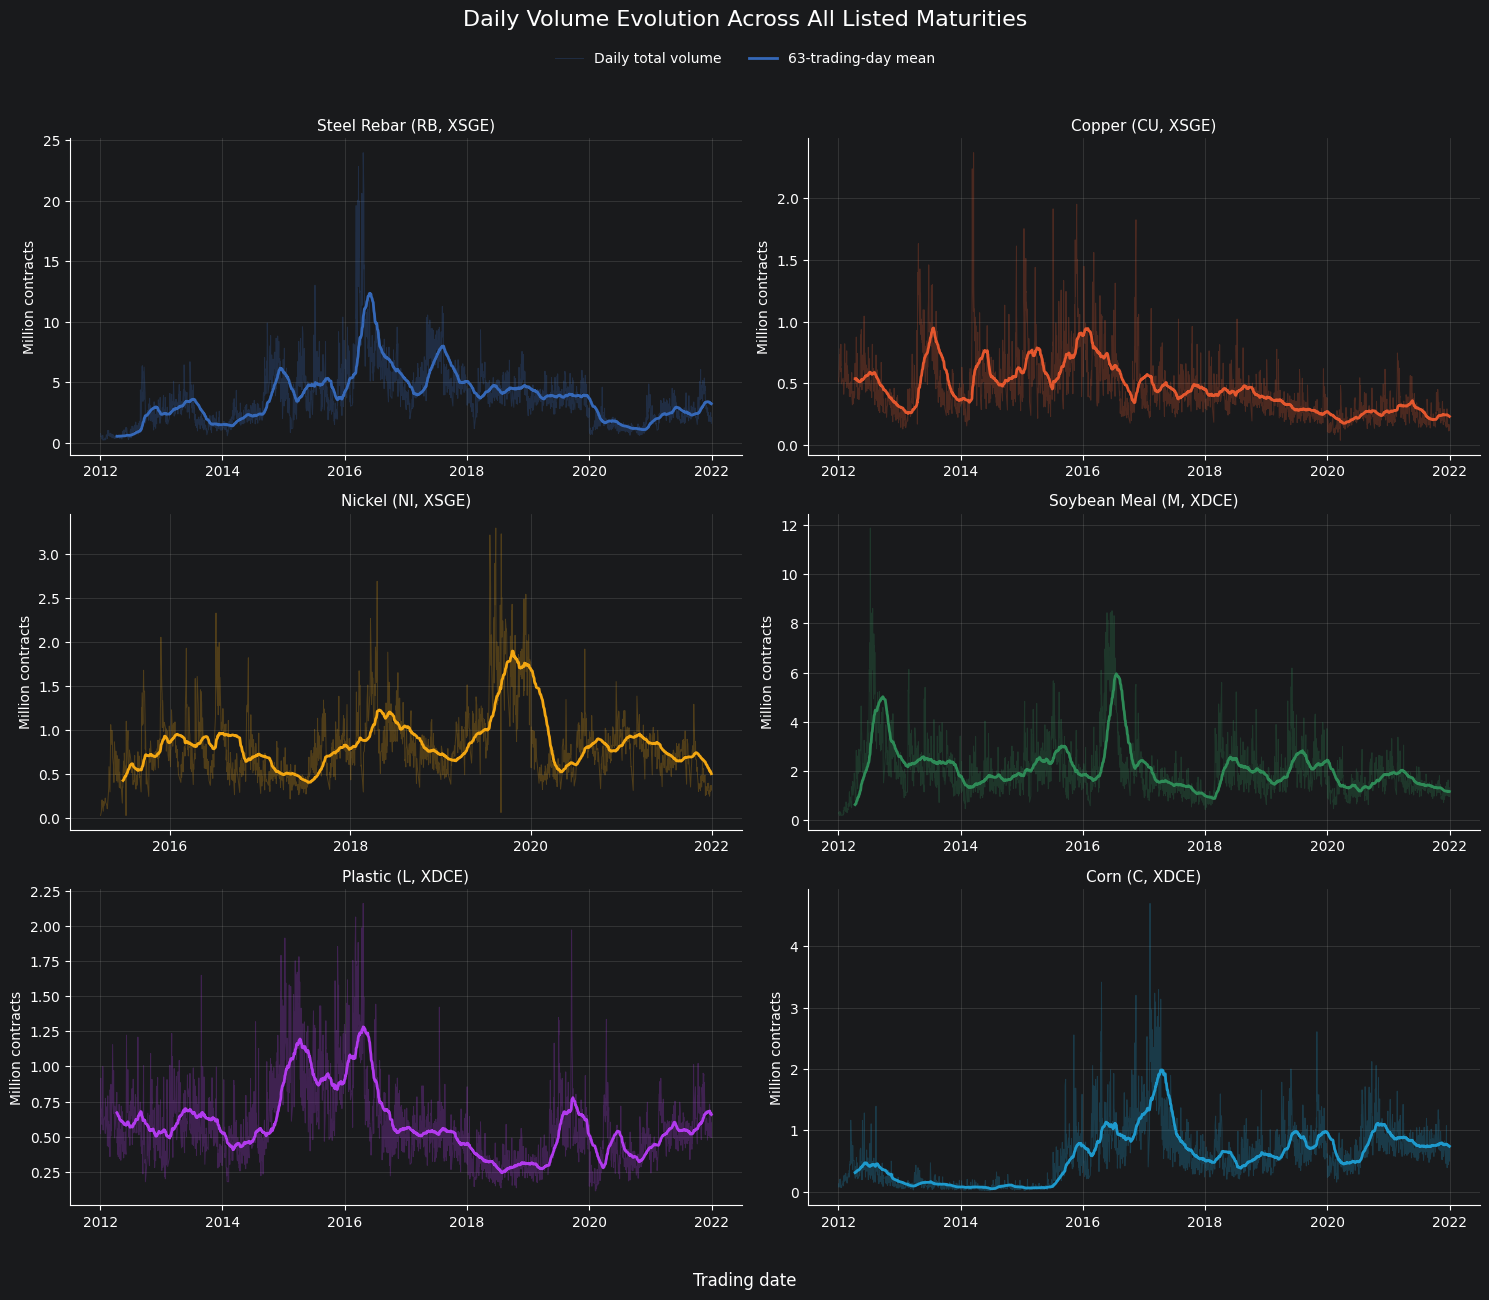

In [20]:
colors = {
    ("XSGE", "RB"): "#3568B8",
    ("XSGE", "CU"): "#E4572E",
    ("XSGE", "NI"): "#F3A712",
    ("XDCE", "M"): "#2E8B57",
    ("XDCE", "L"): "#B23AEE",
    ("XDCE", "C"): "#1E9ACD",
}

figure, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=False)
legend_handles = None
for axis, product in zip(axes.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    product_volume_df = volume_daily_df.loc[
        (volume_daily_df["exchange_code"] == product_key[0])
        & (volume_daily_df["underlying_code"] == product_key[1])
    ].sort_values("trading_date")
    if product_volume_df.empty:
        raise AssertionError(f"绘图品种没有数据：{product_key}")

    daily_line = axis.plot(
        product_volume_df["trading_date"],
        product_volume_df["total_volume"] / 1_000_000,
        color=colors[product_key],
        linewidth=0.7,
        alpha=0.25,
        label="Daily total volume",
    )[0]
    moving_average_line = axis.plot(
        product_volume_df["trading_date"],
        product_volume_df["volume_63d_mean"] / 1_000_000,
        color=colors[product_key],
        linewidth=2.0,
        label="63-trading-day mean",
    )[0]
    if legend_handles is None:
        legend_handles = [daily_line, moving_average_line]

    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_ylabel("Million contracts")
    axis.xaxis.set_major_locator(mdates.YearLocator(2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

figure.suptitle(
    "Daily Volume Evolution Across All Listed Maturities",
    fontsize=16,
    y=0.995,
)
figure.supxlabel("Trading date")
figure.legend(
    legend_handles,
    ["Daily total volume", "63-trading-day mean"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.972),
    ncol=2,
    frameon=False,
)
figure.tight_layout(rect=(0, 0.02, 1, 0.95))
plt.show()

## 验证

下面对每个品种第一个完整窗口人工复算均值，并确认图中恰好有六个面板。该验证只针对本 Notebook 的变换，不重复上游已经保证的全表契约。

In [7]:
validated_product_count = 0
for product_key, product_volume_df in volume_daily_df.groupby(
    ["exchange_code", "underlying_code"],
    observed=True,
    sort=True,
):
    product_volume_df = product_volume_df.sort_values("trading_date").reset_index(drop=True)
    if len(product_volume_df) < ROLLING_TRADING_DAYS:
        raise AssertionError(f"不足一个完整移动窗口：{product_key}")
    expected_first_complete_mean = product_volume_df.loc[
        : ROLLING_TRADING_DAYS - 1, "total_volume"
    ].mean()
    actual_first_complete_mean = product_volume_df.loc[
        ROLLING_TRADING_DAYS - 1, "volume_63d_mean"
    ]
    if not np.isclose(
        actual_first_complete_mean,
        expected_first_complete_mean,
        rtol=1e-12,
        atol=1e-9,
    ):
        raise AssertionError(
            f"63 日均线复算不一致：{product_key}，"
            f"期望 {expected_first_complete_mean}，实际 {actual_first_complete_mean}"
        )
    if product_volume_df.loc[: ROLLING_TRADING_DAYS - 2, "volume_63d_mean"].notna().any():
        raise AssertionError(f"完整 63 日前不应产生均线：{product_key}")
    validated_product_count += 1

if validated_product_count != len(PRODUCTS):
    raise AssertionError(
        f"验证品种数不一致：期望 {len(PRODUCTS)}，实际 {validated_product_count}"
    )
if len(axes.flat) != len(PRODUCTS):
    raise AssertionError("图表面板数不是 6")

print(
    f"validation_ok: {validated_product_count} products, "
    f"{len(volume_daily_df):,} aggregated product-day rows, "
    f"{len(axes.flat)} plot panels"
)

validation_ok: 6 products, 13,806 aggregated product-day rows, 6 plot panels


## 如何解释结果

- 浅色线回答“某一天交易了多少”，粗线回答“近一个季度的典型活跃度是多少”。
- 汇总所有固定月份合约后，换月主要表现为合约之间的成交迁移，而不会机械制造整个品种总量断点。
- 六个面板使用各自纵轴尺度，适合比较同一品种随时间的变化，不应用线条高度直接比较不同品种的市场规模。
- 图形中的共同转折可能与监管、宏观环境或品种自身周期相关；本统计是描述性证据，不构成因果识别。